# CS171 Project
## Trash Sorting RCNN

**Author** - Helena Thiessen

-----

### Project Objective

In a world that is seeing a rapid increase in waste production and feeling the effects of environmental damage from pollution, it is more important than ever to recycle and create a cleaner earth. Most drink containers are recyclable and yet only 43% of aluminum cans, 40% of glass bottles, and 20% of PET plastic bottles are recycled in the United States. This project aims to create a **Regional Convolutional Network** (RCNN) model that can **detect** recyclable drink containers within an image. In a real world application, this will allow the drink containers to be identified so they can be removed for recycling.

-----

### Model Overview

## 1. Project Setup
- Install any missing requirements
- Run the preprocessing notebook for access to the dataset class
- Import necessary libraries

In [2]:
#installs for libraries if necessary
#these are libraries that weren't installed as part of cs171 env
#uncomment to install or add other instals as needed

#!pip install opencv-python
#!pip install torchmetrics[detection]
#!pip install natsort
#!pip install seaborn

running preprocess.ipynb gives access to the following:

- Class: RCNN_Data(root_dir, transforms), set up specifically to accept Drinking Waste Classification dataset, not immediately transferrable to other structures of data
- Func: draw_boxes(images, targets, pred_targets, nms), draws actual and predicted boxes nms filtered by threshold value set as nms
- Func: nms_filter(pred, iou_threshold), filters predictions based on threshold value

In [33]:
#run the preprocess notebook to gain access to classes and functions
%run preprocess.ipynb

Using device: cuda


In [34]:
import torch.nn as nn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
from torchmetrics.detection import MeanAveragePrecision
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# To do
- discuss tuning process
- clean up, comment

## 2. RCNN Model
- Define a custom backbone
- Define a training loop

### Backbone design

Pretrained models such as resnet provide powerful starting points for building effective models or can be used on their own as a standalone model or backbone. Since the purpose of this project is learning and not perfect models, I decided to build a custom backbone to learn about the structure of backbones within RCNN models. I began with multiple iterations of a basic CNN architecture as my backbone but even through increasing size and complexity my maximum test mAP achieved was 0.63, admittedly impressive for such a simple solution albeit insufficient for practical use. Then, wanting to keep with creating a custom backbone for the experience of it, I decided to create a backbone that built on top of resnet34. This leverages the power of resnet while still being able to handmake a custom architecture. The architecture used is as follows:


- 5 layers provided by resnet, layer sizes determined by resnet
- a 3 level feature pyramid network, corresponding to the last 3 resnet layers


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.ops import FeaturePyramidNetwork

class Custom_Backbone(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()

        resnet = torchvision.models.resnet34(weights="IMAGENET1K_V1")
        c3, c4, c5 = 128, 256, 512

        # resnet layers
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1   
        self.layer2 = resnet.layer2   
        self.layer3 = resnet.layer3   
        self.layer4 = resnet.layer4   

        # Feature pyramid network
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=[c3, c4, c5],
            out_channels=out_channels
        )

        # Required by FasterRCNN
        self.out_channels = out_channels

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        c3 = self.layer2(x)      
        c4 = self.layer3(c3)     
        c5 = self.layer4(c4)     

        f = self.fpn({"c3": c3,"c4": c4, "c5": c5})
        return f


In [3]:
with open("RCNNBackbone.py", "w") as f:
    f.write("""
import torch
import torch.nn as nn
import torchvision
from torchvision.ops import FeaturePyramidNetwork

class RCNNBackbone(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()

        resnet = torchvision.models.resnet34(weights="IMAGENET1K_V1")
        c3, c4, c5 = 128, 256, 512

        # resnet layers
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1   
        self.layer2 = resnet.layer2   
        self.layer3 = resnet.layer3   
        self.layer4 = resnet.layer4   

        # Feature pyramid network
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=[c3, c4, c5],
            out_channels=out_channels
        )

        # Required by FasterRCNN
        self.out_channels = out_channels

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        c3 = self.layer2(x)      
        c4 = self.layer3(c3)     
        c5 = self.layer4(c4)     

        f = self.fpn({"c3": c3,"c4": c4, "c5": c5})
        return f

""")

In [ ]:
def training_loop(model, optimizer, scheduler, NUM_EPOCHS, train_loader, test_loader, printing=True): 
    test_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    train_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    test_maps = []
    train_losses = []
    train_maps = []
    
    for epoch in range(NUM_EPOCHS):
        train_metric.reset()
        
        # Run the training loop
        model.train()
        total_train_loss = 0.0

        for train_inputs, train_labels in train_loader:
            train_inputs = list(image.to(device) for image in train_inputs)
            train_labels = [{k: v.to(device) for k, v in t.items()} for t in train_labels]

            optimizer.zero_grad()
            train_loss_dict = model(train_inputs, train_labels)
            loss = sum(train_loss_dict.values())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()

            model.eval()
            with torch.no_grad():
                preds = model(train_inputs)  
                train_metric.update(preds, train_labels)
            model.train()

            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_map_results = train_metric.compute()
        train_maps.append(train_map_results['map'])
        
        
        # Run the testing loop
        model.eval()
        with torch.no_grad():
            for test_inputs, test_labels in test_loader:
                test_inputs = list(image.to(device) for image in test_inputs)
                test_labels = [{k: v.to(device) for k, v in t.items()} for t in test_labels]
                
                predictions = model(test_inputs)
                test_metric.update(predictions, test_labels)

            test_map_results = test_metric.compute()
            test_maps.append(test_map_results['map'])
            test_metric.reset()

        scheduler.step()
        if printing:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}"+\
                  f" - Train Loss: {avg_train_loss:.4f} ", end = " ")
            print(f"- Train Map {train_map_results['map'].item():.4f}", end = " ")
            print(f"- Test  Map {test_map_results['map'].item():.4f}")

    return train_losses,test_maps, train_maps

## 3. Train on Drinking Waste Classification Dataset

- Define a collate function
- Define transforms
- Create dataloaders
- Create model instance
- Run training loop
- Save model

In [ ]:
#Collate function
#Combines provided samples into a structured batch
def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

For use in detection model it is necessary to ensure that transforms will not impact the bounding boxes. When using pytorch transforms this then may require some alterations to ensure that the boxes are preserved with the transform action. Below I define and compose transforms for my training data.

In [38]:
class ComposeDet:
    def __init__(self, ts): self.ts = ts
    def __call__(self, img, target):
        for t in self.ts:
            img, target = t(img, target)
        return img, target

class RandomHorizontalFlipDet:
    def __init__(self, p=0.5): self.p = p
    def __call__(self, img, target):
        if torch.rand(1) < self.p:
            _, H, W = img.shape
            img = TF.hflip(img)
            b = target["boxes"].clone()
            x1,y1,x2,y2 = b.unbind(1)
            b[:,0] = W - x2
            b[:,2] = W - x1
            target["boxes"] = b
        return img, target

class ColorJitterDet:
    def __init__(self, b=0.25, c=0.25, s=0.25, h=0.02):
        self.j = T.ColorJitter(b,c,s,h)
    def __call__(self, img, target):
        return self.j(img), target


train_tfms = ComposeDet([
    RandomHorizontalFlipDet(0.5),
    ColorJitterDet(0.25,0.25,0.25,0.02),
])

In [39]:
#creating data loaders, 0 workers
#tune batch size and num workers to your machine
root = Path.cwd() / "Images_of_Waste" / "YOLO_imgs"

ds = RCNN_Data(root)

split = 0.8
train_size = int(len(ds) * split)
test_size = len(ds) - train_size 

#split with a random split because all classes are proportionally represented
train_ds,test_ds = random_split(ds, [train_size, test_size])


train_ds.dataset.transforms = train_tfms   
test_ds.dataset.transforms  = None         

train_loader = DataLoader(
    train_ds,
    batch_size=10,           
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=10,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [42]:
from torchvision.ops import MultiScaleRoIAlign
backbone = Custom_Backbone()
    
anchor_generator = AnchorGenerator(
        sizes=(
        (32, 48, 64),     
        (96, 128, 160),   
        (192, 256, 320),  
    ), 
    aspect_ratios=((0.5, 1.0, 2.0),) * 3               
)

model = FasterRCNN(backbone, num_classes=5, rpn_anchor_generator=anchor_generator).to(device)


model.transform.min_size = [448, 512, 576]
model.transform.max_size = 896 

model.roi_heads.box_roi_pool = MultiScaleRoIAlign(
    featmap_names=["c3", "c4", "c5"],  # must match keys from backbone
    output_size=7,
    sampling_ratio=2,
)

optimizer = torch.optim.SGD(
    model.parameters(), momentum=0.9, weight_decay=1e-4, nesterov=True
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)


In [43]:
NUM_EPOCHS = 20

train_losses, test_maps, train_maps = training_loop(
        model, optimizer, scheduler, NUM_EPOCHS, train_loader, test_loader, printing=True
)

Epoch 1/20 - Train Loss: 0.4218  - Train Map 0.0204 - Test  Map 0.1396
Epoch 2/20 - Train Loss: 0.2482  - Train Map 0.3402 - Test  Map 0.4698
Epoch 3/20 - Train Loss: 0.1691  - Train Map 0.5501 - Test  Map 0.5609
Epoch 4/20 - Train Loss: 0.1381  - Train Map 0.6244 - Test  Map 0.6369
Epoch 5/20 - Train Loss: 0.1204  - Train Map 0.6658 - Test  Map 0.6400
Epoch 6/20 - Train Loss: 0.1102  - Train Map 0.6945 - Test  Map 0.6637
Epoch 7/20 - Train Loss: 0.1047  - Train Map 0.7144 - Test  Map 0.6764
Epoch 8/20 - Train Loss: 0.0998  - Train Map 0.7321 - Test  Map 0.7107
Epoch 9/20 - Train Loss: 0.0910  - Train Map 0.7525 - Test  Map 0.7259
Epoch 10/20 - Train Loss: 0.0895  - Train Map 0.7572 - Test  Map 0.7300
Epoch 11/20 - Train Loss: 0.0892  - Train Map 0.7622 - Test  Map 0.7266
Epoch 12/20 - Train Loss: 0.0884  - Train Map 0.7640 - Test  Map 0.7322
Epoch 13/20 - Train Loss: 0.0879  - Train Map 0.7638 - Test  Map 0.7283
Epoch 14/20 - Train Loss: 0.0871  - Train Map 0.7655 - Test  Map 0.7341
E

In [45]:
model.eval()
test_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=False).to(device)

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = [im.to(device) for im in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]
        preds = model(imgs)
        test_metric.update(preds, targets)

res = test_metric.compute()

print("mAP@[0.5:0.95]:", res["map"].item())
print("mAP@0.5:",       res["map_50"].item())
print("mAP@0.75:",      res["map_75"].item())

mAP@[0.5:0.95]: 0.742688000202179
mAP@0.5: 0.9837315082550049
mAP@0.75: 0.8947438597679138


Training is time consuming (2 hours on my GPU) so the model is saved so it can be used without needing to retrain as well as the metrics recorded during training so these can be visualized without retraining the model.

In [4]:
#commented out because I only wanted to save once to not overwrite the model used in analysis

#save model and recorded metrics
#torch.save(model.state_dict(), "model.pt")
#np.savetxt("test_map.txt", test_maps)
#np.savetxt("train_map.txt", train_maps)
#np.savetxt("train_loss.txt", train_losses)

## 4. Assess Training Results
(some may be moved to analysis notebook)

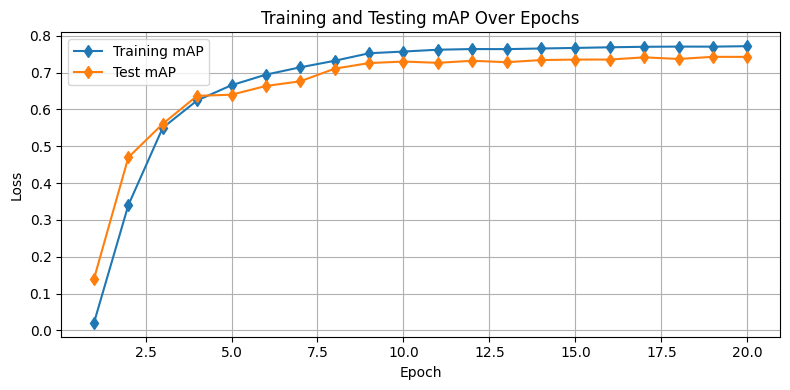

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_maps, 'd-', label='Training mAP')
plt.plot(range(1, NUM_EPOCHS + 1), test_maps, 'd-', label='Test mAP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing mAP Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

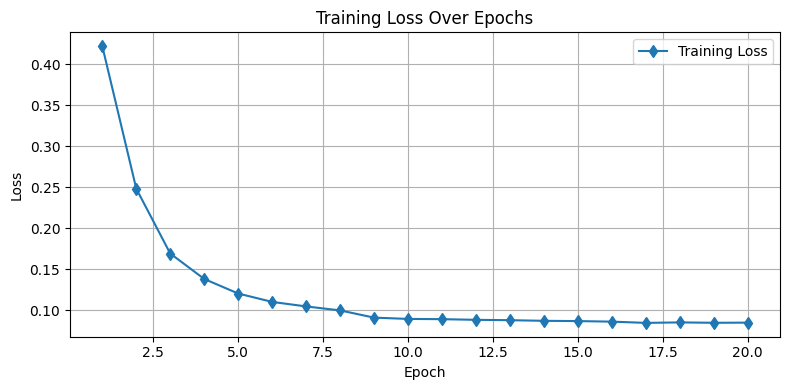

In [47]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'd-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()